# **Exercise 2**: Analyse your SFINCS model for Charleston

In this exercise we will analyse the results of the SFINCS model for the area around Charleston that you just ran. 
After doing this exercise you will know how to do a basic visualisation of the output. 

We will follow the following steps to create the model:

- Step 0: Import dependencies
- Step 1: Load simulated model
- Step 2: Model output
- Step 3: Plot time-series
- Step 4: Plot map output
- Step 5: Quick video
- Step 6: Plot maximum water levels
- Step 7: Investigate the model input

## **Step 0:** Import dependencies

Before anything else we need to import the required packages:

In [1]:
import os
from pathlib import Path

from hydromt_sfincs import SfincsModel

## **Step 1:** Load simulated model
The first step is to load the simulated model results by providing:
 - `root_folder`: Folder where the model was saved. Path is relative to current working directory. We are loading in the model "Charleston_subgrid_example_basicforcing"

In [2]:
root_folder  = Path('../Charleston_subgrid_example_basicforcing')

sf = SfincsModel(root=root_folder, mode='r')
sf.read()

## **Step 2:** Model output

In the previous notebook we have run the SFINCS simulation, and looked at the logfile of the model.
Now we will look at the actual output of the model, these are saved in the Netcdf files called:
 - `sfincs_map.nc`: File for all the spatially varying data like the water levels in the entire domain.
 - `sfincs_his.nc`: (optional) File with the time-series at observations points, in case these were provided.

We will now load in the results using HydroMT, and look at what data is available:

In [3]:
sf.read_results()
print(sf.results.keys())

dict_keys(['inp', 'msk', 'zb', 'zs', 'zsmax', 'total_runtime', 'average_dt', 'status', 'point_zb', 'point_zs'])


Available are, from sfincs_map.nc:
 - `inp`: All input settings provided to the sfincs input file
 - `msk`: Mask of active cells, will be explained later 
 - `zb`: Bed level elevation 
 - `zs`: Water level in time on the whole grid 
 - `zsmax`: Maximum water level observed during a certain interval (e.g. every day) on the whole grid 
  - `total_runtime`: Total simulation time, as can also be read in 'sfincs_log.txt'   
  - `average_dt`: Average model time step, as can also be read in 'sfincs_log.txt'  

Available are, from sfincs_his.nc:
 - `point_zb`: Bed level elevation at specific observation points
 - `point_zs`: Water level in time at specific observation points

 *Hint*: More information about e.g. units can be found in the online SFINCS documentation: https://sfincs.readthedocs.io/en/latest/output.html#output-description 

## **Step 3:** Plot time-series
Let's have a look at the time-series of the first observation point, at 'Charleston river mouth':

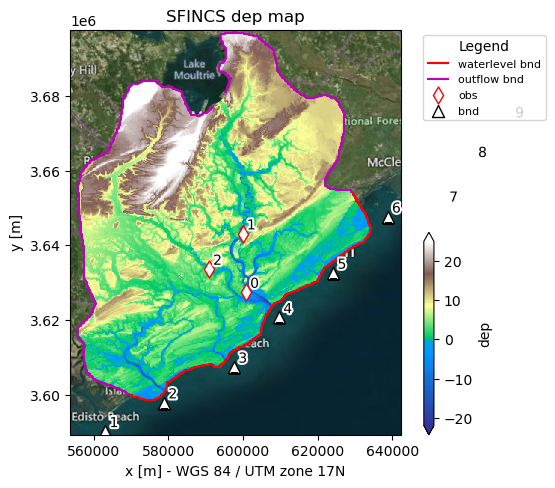

In [4]:
_ = sf.plot_basemap(variable='dep',bmap='sat')

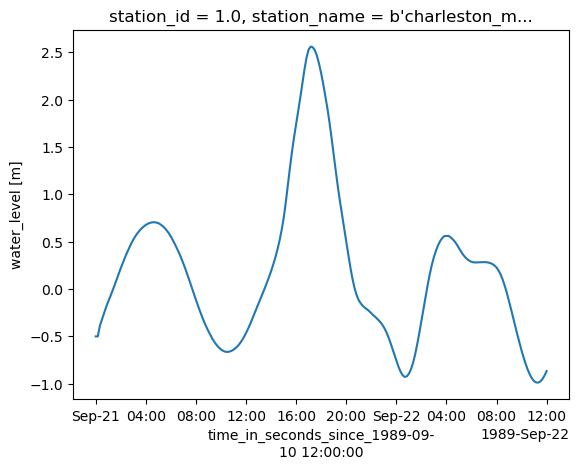

In [5]:
id = 0 # first observation point
sf.results['point_zs'][:,id].plot.line(x='time')

## Question 1

1a) What is the maximum water level in the mouth of the river?

1b) And how much is this in Ashley River?

1c) Why do you think there is a difference?

In [6]:
# Make your own code for b) here:


### Fill out your answers:

1a)

1b)

1C)

## Question 2

2a) Can you estimate the tidal contribution to that water level?

2b) And the additional storm surge?

### Fill out your answers:

2a)

2b)

## **Step 4:** Plot map output

Now we can plot for instance the water level at the first timestep.

When opening the result 'zs', we can see that this is load in HydroMT as a Xarray DataArray.
The dimension of the water levels is [time, y, x].

In [7]:
sf.results["zs"]

<xarray.DataArray 'zs' (time: 37, y: 540, x: 440)>
dask.array<open_dataset-zs, shape=(37, 540, 440), dtype=float32, chunksize=(37, 540, 440), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3.59e+06 3.59e+06 3.59e+06 ... 3.697e+06 3.697e+06
    spatial_ref  int32 0
  * x            (x) float64 5.541e+05 5.543e+05 ... 6.417e+05 6.419e+05
  * time         (time) datetime64[ns] 1989-09-21 ... 1989-09-22T12:00:00
Attributes:
    units:          m
    standard_name:  sea_surface_height_above_reference_level
    long_name:      water_level

Let's plot the initial water level at the start of the simulation:

(<Figure size 600x525.974 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS zs map'}, xlabel='x [m] - WGS 84 / UTM zone 17N', ylabel='y [m]'>)

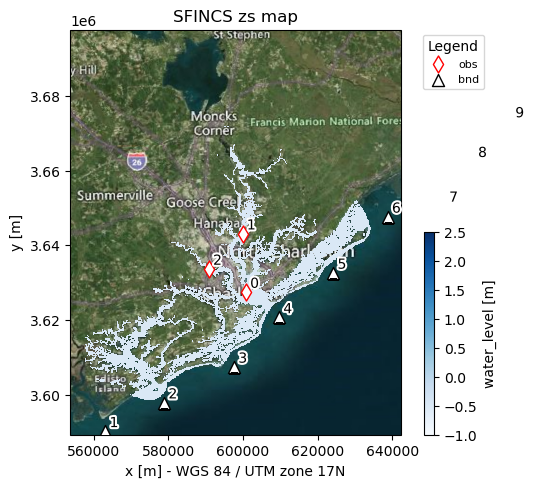

In [8]:
itime = 0 # first output timestep

# get water level at first output timestep
zs =  sf.results["zs"][itime,:,:]

sf.plot_basemap(
    variable=zs,
    bmap='sat', 
    plot_bounds=False,
    vmin = -1, # set min and max values for colorbar
    vmax = 2.5, # set min and max values for colorbar
    cmap = 'Blues', # set colormap
) 

## Question 3

3a) Can you plot the water level during the peak of the storm? 

3b) Is a much larger area flooded then?

### Fill out your answers:

3a)

3b)

## **Step 5:** Quick video
Using some Python magic, we can show the water levels in a quick movie.
After running the script, scroll down and hit play!

In [9]:
import sfincs_plotting

# Get water level variable from results
da_zs = sf.results["zs"].load()

# Make animation
sfincs_plotting.make_animation(
    da_zs=da_zs,
    geoms=sf.geoms,
    bmap = "sat", 
    figsize=(7, 7)
    )

## Question 4

4a) From what direction comes the largest flood wave?

4b) Do you think Hurricane Hugo (1989), that created this storm surge, made landfall west or east from the city of Charleston?

4c) Do you think the impact would have been more intense if the hurricane would have made landfall more to the south?

*Hint* - you can see the track here:  https://coast.noaa.gov/hurricanes/ if you type in 'Hurricane Hugo'

### Fill out your answers:

4a)

4b)

4c)

## **Step 6:** Plot maximum water levels
Besides showing the water levels in time, we can also have a look at the maximum water level over the whole simulation:


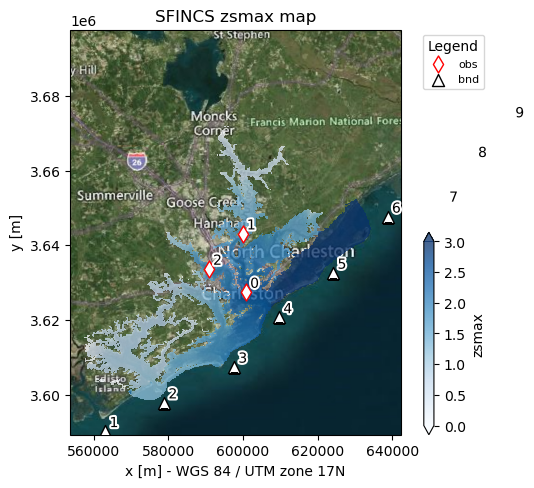

In [10]:
%matplotlib inline
# %matplotlib qt

# Get maximum water levels over time
zsmax = sf.results["zsmax"].max(dim='timemax')

# Plot maximum water levels
_ = sf.plot_basemap(
        variable=zsmax,
        bmap='sat', 
        plot_bounds=False, 
        vmin = 0, 
        vmax = 3, 
        cmap = 'Blues', 
        alpha=0.75
    )

*Tip* - if you add '%matplotlib qt' above the current code in the cell above, you can make this figure come out in a separate window, so you can e.g. zoom in.
Reversing this can be done with '%matplotlib inline'

Note that we are not looking yet at water depths, for this we will do a downscaling procedure later in the course, but for that we first need to concept of our subgrid approach.

## **Step 7:** Investigate the model input
The SFINCS model of Charleston of which you analysed the results, consists of a number of input files.
Below we will ask you some questions about these.

Information (if needed) can also be found in the online SFINCS manual on ReadtheDocs: https://sfincs.readthedocs.io/en/latest/index.html

An overview of relevant pages:
- `General model input`:            https://sfincs.readthedocs.io/en/latest/input.html
- `Model forcing`:                  https://sfincs.readthedocs.io/en/latest/input_forcing.html
- `Model features as structures`:   https://sfincs.readthedocs.io/en/latest/input_structures.html
- `All input parameters`:           https://sfincs.readthedocs.io/en/latest/parameters.html
- `All input files`:                https://sfincs.readthedocs.io/en/latest/parameters.html#input-files
- `All output variables`:           https://sfincs.readthedocs.io/en/latest/output.html#output-description

Because HydroMT has loaded in all the information of the existing simulation, you can find the information of input parameters and files in sf.config (dictionary)

In [11]:
sf.config

{'mmax': 440,
 'nmax': 540,
 'dx': 200,
 'dy': 200,
 'x0': 553971,
 'y0': 3589492,
 'rotation': 0,
 'epsg': 32617,
 'latitude': 32.78,
 'utmzone': '17N',
 'tref': datetime.datetime(1989, 9, 10, 12, 0),
 'tstart': datetime.datetime(1989, 9, 21, 0, 0),
 'tstop': datetime.datetime(1989, 9, 22, 12, 0),
 'dtout': 3600,
 'dthisout': 600,
 'dtmaxout': 86400,
 'alpha': 0.5,
 'huthresh': 0.005,
 'zsini': -0.5,
 'qinf': 0,
 'advection': 0,
 'stopdepth': 100,
 'depfile': 'sfincs.dep',
 'mskfile': 'sfincs.msk',
 'indexfile': 'sfincs.ind',
 'bndfile': 'sfincs.bnd',
 'bzsfile': 'sfincs.bzs',
 'sbgfile': 'sfincs.sbg',
 'obsfile': 'sfincs.obs',
 'inputformat': 'bin',
 'outputformat': 'net',
 'advlim': 9999}

However, we can also go back to the original input files to run SFINCS 'sfincs.inp':

In [12]:
with open(os.path.join(root_folder,"sfincs.inp")) as f: 
    print(f.read())

mmax           = 440
nmax           = 540
dx             = 200
dy             = 200
x0             = 553971
y0             = 3589492
rotation       = 0
latitude       = 32.78
utmzone        = 17N
epsg           = 32617
tref           = 19890910 120000
tstart         = 19890921 000000
tstop          = 19890922 120000
dtout          = 3600
dthisout       = 600
dtmaxout       = 86400
alpha          = 0.5
huthresh       = 0.005
zsini          = -0.5
qinf           = 0
advection      = 0
advlim         = 9999
stopdepth      = 100
depfile        = sfincs.dep
mskfile        = sfincs.msk
indexfile      = sfincs.ind
bndfile        = sfincs.bnd
bzsfile        = sfincs.bzs
sbgfile        = sfincs.sbg
obsfile        = sfincs.obs
inputformat    = bin
outputformat   = net


## Question 5

5a) Do you see any differences between the 2 list?

5b) How long is the simulation period?

5c) Why do you think in HydroMT the times are available as datetime.datetime?

5d) What is the resolution of the Charleston model and how many grid-cells do we have?

5e) Can you find how many cells are active in the domain?  (Hint, look back at the sfincs.log file)

### Fill out your answers:

5a)

5b)

5c)

5d)

5e)


We can also look at specific input files, like e.g. sfincs.bnd:

In [13]:
with open(os.path.join(root_folder,"sfincs.bnd")) as f: 
    print(f.read())

  563174.4  3590215.0
  578937.0  3597887.6
  597643.3  3607465.5
  609687.7  3620705.1
  624198.1  3632615.6
  638754.4  3647619.4
  654074.3  3650560.4
  661806.2  3662515.2
  671766.7  3673148.8



## Question 6

6a) How many boundary input points do we have?

6b) And how many river upstream discharge input points?

### Fill out your answers:

6a)

6b)

## **BONUS:** Change some settings and re-analyse the results:
- Run the simulation with advection and compare the results with the base run, how big is the difference? And how much slower did the simulation become?
- Run the model in the folder 'Charleston_subgrid_example_allforcing' that contains more forcing. What extra forcings are added? And do you see the effect in the results? How much additional water level increase do you see at the mouth of the river because of the local wind setup? How much is the flooding reduced in extent/water level due to the weir?

## **Done:**


Congrats, you did your first analysis of SFINCS model results!

Now you can continue with actually setting up your own first SFINCS model in the notebook: *SFINCS_course_03_model_setup.ipynb*

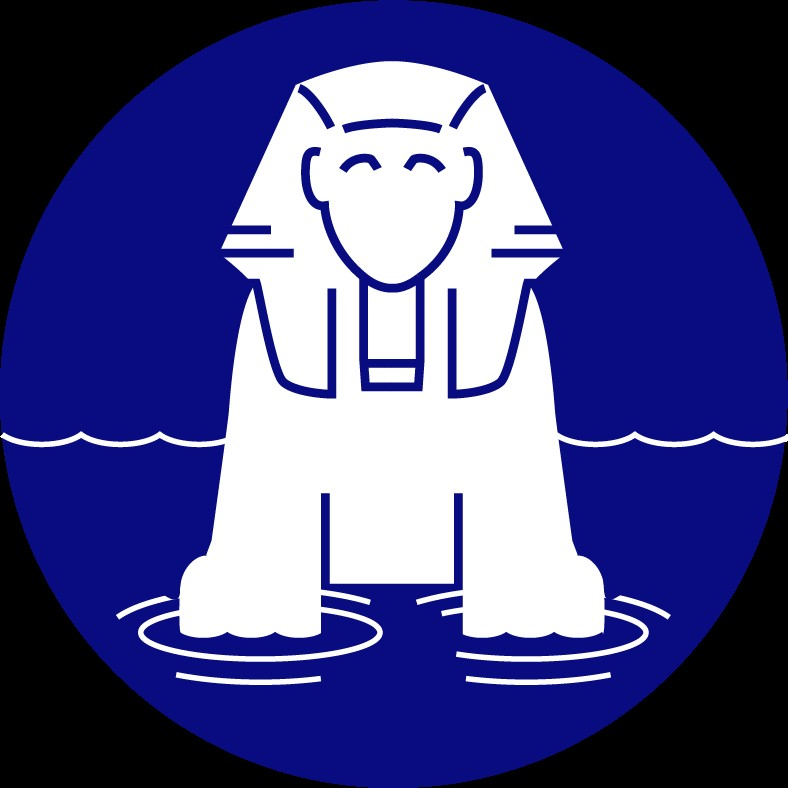